Matplotlib is building the font cache; this may take a moment.


Stage 1: Starting fast RFE (11,000 -> 500)...
Coarse feature elimination completed. Remaining features: 500
Stage 2: Searching for the optimal number of features using RFECV (Step=50)...
Optimal number of features identified: 450


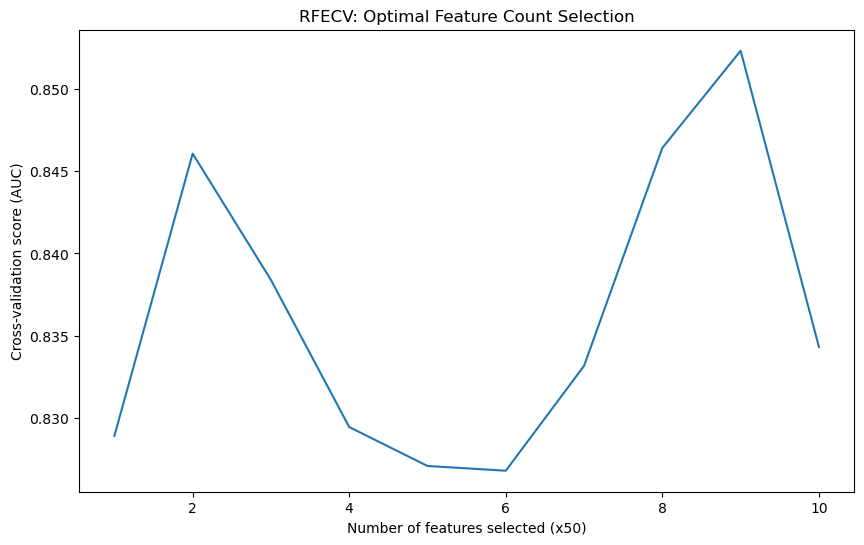

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Data Preparation
df = pd.read_csv('merged_data.csv')
metadata_cols = ['sample_id', 'Gender', 'Race', 'Diagnosis']
X = df.drop(columns=metadata_cols)
y = df['Diagnosis'].map({'Control': 0, 'AD': 1})

# 2. Stage 1: Coarse Feature Elimination (11k -> 500)
print("Stage 1: Starting fast RFE (11,000 -> 500)...")
estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
coarse_selector = RFE(estimator, n_features_to_select=500, step=500)
coarse_selector.fit(X, y)

X_500 = X.iloc[:, coarse_selector.support_]
print(f"Coarse feature elimination completed. Remaining features: {X_500.shape[1]}")

# 3. Stage 2: Fine Feature Selection and Optimal Feature Count Determination (500 -> Optimal)
# RFECV performs cross-validation at each step (step=50) to identify the number of features
# that yields the highest AUC score
print("Stage 2: Searching for the optimal number of features using RFECV (Step=50)...")
cv = StratifiedKFold(5)
fine_selector = RFECV(
    estimator=estimator,
    step=50,
    cv=cv,
    scoring='roc_auc',
    min_features_to_select=50,
    n_jobs=-1
)
fine_selector.fit(X_500, y)

X_optimal = X_500.iloc[:, fine_selector.support_]
optimum_count = X_optimal.shape[1]
print(f"Optimal number of features identified: {optimum_count}")

# 4. Applying NMF on the Selected Optimal Features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_optimal)

# The number of factors (k) is set to 5 based on the complexity of the dataset
k_final = 5
nmf = NMF(n_components=k_final, init='nndsvd', random_state=42, max_iter=1000)
W = nmf.fit_transform(X_scaled)
H = nmf.components_

# 5. Saving Results and Preparing Visualizations
patient_scores = pd.DataFrame(W, columns=[f'Factor_{i+1}' for i in range(k_final)])
patient_scores['Diagnosis'] = df['Diagnosis'].values

# RFECV Performance Plot (to visualize the optimal feature selection point)
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected (x50)")
plt.ylabel("Cross-validation score (AUC)")
plt.plot(range(1, len(fine_selector.cv_results_['mean_test_score']) + 1), 
         fine_selector.cv_results_['mean_test_score'])
plt.title("RFECV: Optimal Feature Count Selection")
plt.savefig('rfecv_optimization_curve.png')
plt.show()

# Save feature loadings
feature_loadings = pd.DataFrame(H, columns=X_optimal.columns, index=[f'F{i+1}' for i in range(k_final)])
feature_loadings.to_csv('optimal_rfe_nmf_loadings.csv')

In [2]:
from sklearn.model_selection import cross_val_score

# ----------------------------
# 6. Predictive Performance (AUC) of RFECV-Selected Optimal Features
# ----------------------------
estimator_auc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# ROC AUC evaluation using 5-fold cross-validation
cv_scores = cross_val_score(estimator_auc, X_optimal, y, cv=5, scoring='roc_auc')

print(f"Predictive performance (AUC) of the {X_optimal.shape[1]} features selected after RFECV: "
      f"{cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

Predictive performance (AUC) of the 450 features selected after RFECV: 0.83 (+/- 0.04)


Phase 1: Coarse RFE (11,000 -> 500)...
Phase 2: Fine RFECV Optimization (Step=50)...
Optimal feature count identified: 450
Plotting the most significant factors: Factor_3 (p=2.27e-11) and Factor_2


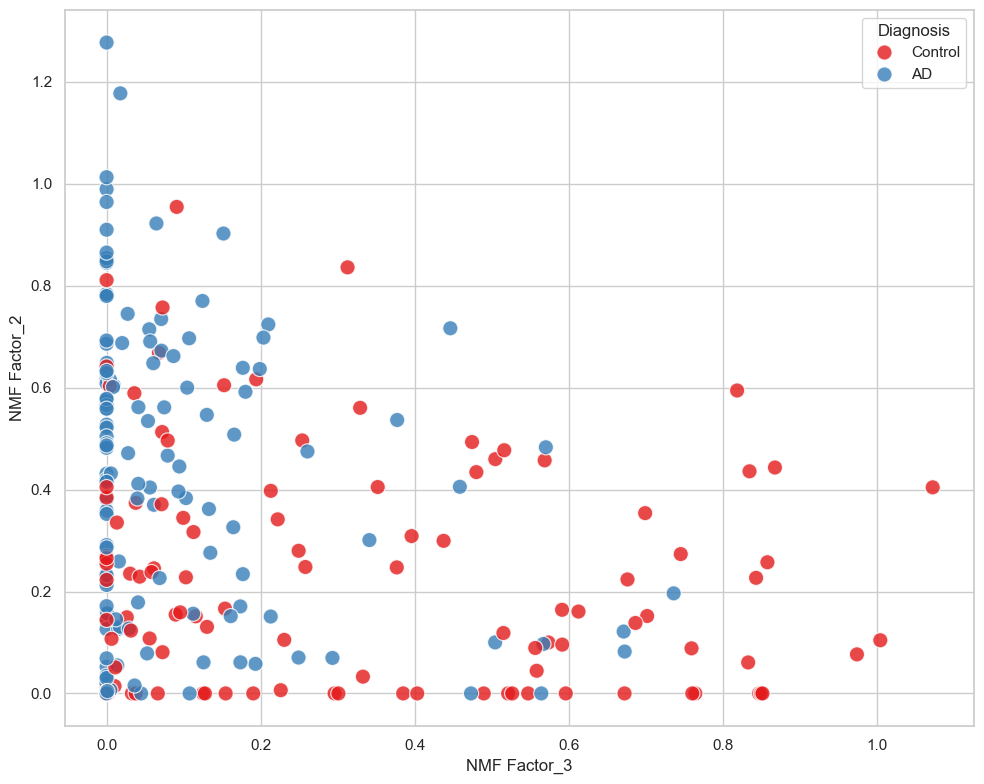

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold
from scipy import stats

# 1. Data Preparation
df = pd.read_csv('merged_data.csv')
metadata_cols = ['sample_id', 'Gender', 'Race', 'Diagnosis']
X = df.drop(columns=metadata_cols)
y = df['Diagnosis'].map({'Control': 0, 'AD': 1})

# 2. RFECV: Two-Stage Optimal Feature Selection
# Phase A: 11k -> 500 (coarse feature elimination)
print("Phase 1: Coarse RFE (11,000 -> 500)...")
coarse_selector = RFE(RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42), 
                      n_features_to_select=500, step=500)
coarse_selector.fit(X, y)
X_500 = X.iloc[:, coarse_selector.support_]

# Phase B: 500 -> Optimal (AUC optimization with steps of 50 features)
print("Phase 2: Fine RFECV Optimization (Step=50)...")
rfecv = RFECV(estimator=RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
              step=50, cv=StratifiedKFold(5), scoring='roc_auc', min_features_to_select=50)
rfecv.fit(X_500, y)
X_optimal = X_500.iloc[:, rfecv.support_]
print(f"Optimal feature count identified: {X_optimal.shape[1]}")

# 3. NMF Analysis on the Selected Optimal Features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_optimal)
k_final = 5
nmf = NMF(n_components=k_final, init='nndsvd', random_state=42, max_iter=1000)
W = nmf.fit_transform(X_scaled)
H = nmf.components_

# Convert results into a DataFrame
patient_scores = pd.DataFrame(W, columns=[f'Factor_{i+1}' for i in range(k_final)])
patient_scores['Diagnosis'] = df['Diagnosis'].values

# 4. Identification of the Most Significant Factors (Automated)
factor_p_values = {}
for col in [f'Factor_{i+1}' for i in range(k_final)]:
    group_ad = patient_scores.loc[patient_scores['Diagnosis'] == 'AD', col]
    group_ctrl = patient_scores.loc[patient_scores['Diagnosis'] == 'Control', col]
    _, p = stats.ttest_ind(group_ad, group_ctrl)
    factor_p_values[col] = p

# Select the two factors with the lowest p-values
best_factors = sorted(factor_p_values, key=factor_p_values.get)[:2]
f_x, f_y = best_factors[0], best_factors[1]
print(f"Plotting the most significant factors: {f_x} (p={factor_p_values[f_x]:.2e}) and {f_y}")

# 5. Visualization (Manuscript-Ready Format - English and No Title)
output_dir = 'rfe_nmf_results'
os.makedirs(output_dir, exist_ok=True)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))
sns.scatterplot(data=patient_scores, x=f_x, y=f_y, hue='Diagnosis', 
                palette='Set1', s=120, alpha=0.8, edgecolor='w')
plt.xlabel(f'NMF {f_x}')
plt.ylabel(f'NMF {f_y}')
plt.legend(title='Diagnosis', frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'final_rfe_nmf_scatter.png'), dpi=300)
plt.show()

# Save feature loadings (H matrix)
feature_loadings = pd.DataFrame(H, columns=X_optimal.columns, index=[f'F{i+1}' for i in range(k_final)])
feature_loadings.to_csv(os.path.join(output_dir, 'optimal_feature_loadings.csv'))

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# ---------------------------------------------------------
# 1. Statistical Analysis: Association Between Factors and Diagnosis
# ---------------------------------------------------------
factor_columns = [col for col in patient_scores.columns if 'Factor' in col]
stats_list = []

for col in factor_columns:
    group_ad = patient_scores.loc[patient_scores['Diagnosis'] == 'AD', col]
    group_ctrl = patient_scores.loc[patient_scores['Diagnosis'] == 'Control', col]

    t_stat, p_val = stats.ttest_ind(group_ad, group_ctrl)

    stats_list.append({
        'Factor': col,
        'p_value': p_val,
        't_stat': t_stat
    })

# Sort by significance
stats_df = pd.DataFrame(stats_list).sort_values('p_value')

print("Which factors are more strongly associated with the disease?")
print(stats_df.to_string(index=False))


# ---------------------------------------------------------
# 2. Plot Preparation
# ---------------------------------------------------------
output_dir = "final_plots_nmf"
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 12})


# ---------------------------------------------------------
# PLOT 1: NMF Scatter Plot (Factor 3 vs Factor 2)
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=patient_scores,
    x="Factor_3",
    y="Factor_2",
    hue="Diagnosis",
    palette="Set1",
    s=120,
    alpha=0.7,
    edgecolor="white"
)

plt.xlabel("NMF Factor 3")
plt.ylabel("NMF Factor 2")

plt.legend(title="Diagnosis", loc="upper right")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "nmf_scatter_f3_f2.png"),
    dpi=300
)

plt.close()


# ---------------------------------------------------------
# PLOT 2: Combined Boxplots (Factor 3 and Factor 2)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(
    data=patient_scores,
    x="Diagnosis",
    y="Factor_3",
    hue="Diagnosis",
    palette="Set1",
    legend=False,
    ax=axes[0]
)

axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("NMF Factor 3 Weight")


sns.boxplot(
    data=patient_scores,
    x="Diagnosis",
    y="Factor_2",
    hue="Diagnosis",
    palette="Set1",
    legend=False,
    ax=axes[1]
)

axes[1].set_xlabel("Diagnosis")
axes[1].set_ylabel("NMF Factor 2 Weight")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "nmf_boxplots_combined.png"),
    dpi=300
)

plt.close()


# ---------------------------------------------------------
# PLOT 3: KDE Density Plot (Factor 3)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=patient_scores,
    x="Factor_3",
    hue="Diagnosis",
    fill=True,
    common_norm=False,
    palette="Set1",
    alpha=0.4
)

plt.xlabel("NMF Factor 3")
plt.ylabel("Density")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "nmf_kde_factor3.png"),
    dpi=300
)

plt.close()


# ---------------------------------------------------------
# PLOT 4: Top Feature Loadings for Factor 3
# ---------------------------------------------------------
top_n = 15

top_features_f3 = (
    feature_loadings
    .loc["F3"]
    .sort_values(ascending=False)
    .head(top_n)
)

plot_df = pd.DataFrame({
    "Feature": top_features_f3.index,
    "Loading": top_features_f3.values
})

plt.figure(figsize=(10, 8))

sns.barplot(
    data=plot_df,
    x="Loading",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.xlabel("Loading Score")
plt.ylabel("Molecular Features / PGS")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "nmf_top_loadings_f3.png"),
    dpi=300
)

plt.close()


print(f"All plots and statistical results have been processed and saved to '{output_dir}'.")

Which factors are more strongly associated with the disease?
  Factor      p_value    t_stat
Factor_3 2.274503e-11 -6.996249
Factor_2 2.307370e-08  5.767150
Factor_1 1.923949e-02 -2.355702
Factor_5 6.379714e-02  1.861627
Factor_4 7.551440e-02 -1.784547
All plots and statistical results have been processed and saved to 'final_plots_nmf'.


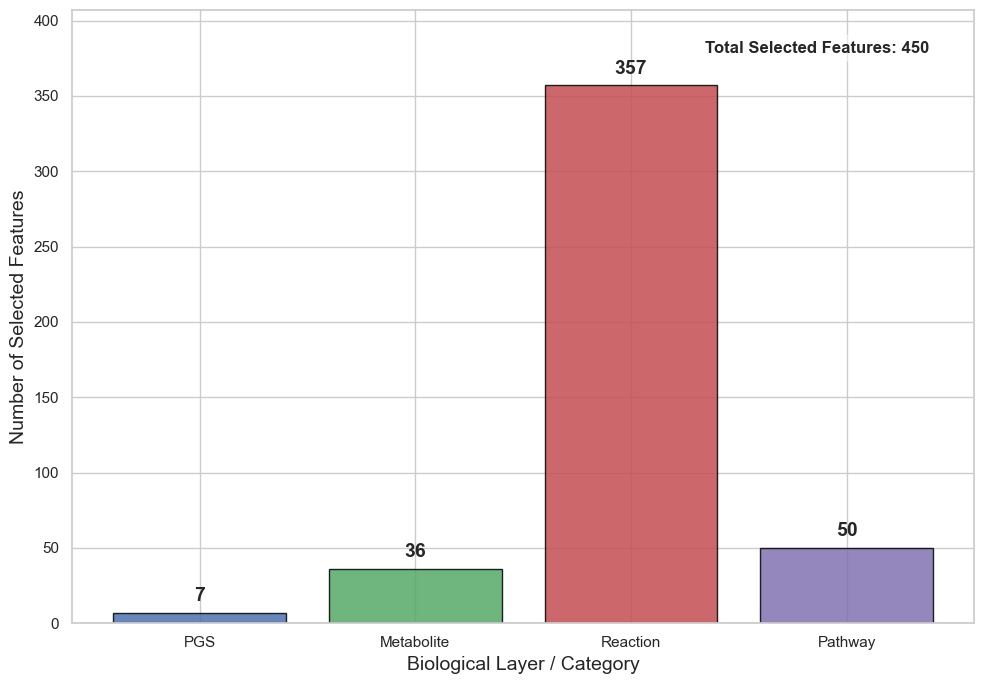

Distribution of the 450 selected features:
PGS             7
Metabolite     36
Reaction      357
Pathway        50
Name: count, dtype: int64


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

"""
Feature distribution analysis across biological layers.

This script:
1. Categorizes selected features into biological layers (PGS, metabolites, reactions, pathways).
2. Quantifies the distribution of selected features across these layers.
3. Generates a publication-ready bar plot summarizing the selected feature composition.
"""

# 1. Color Palette and Visualization Style Settings
category_colors = {
    'PGS': '#4C72B0',        # Blue
    'Metabolite': '#55A868', # Green
    'Reaction': '#C44E52',   # Dark red
    'Pathway': '#8172B3'     # Purple (Yellow removed)
}
sns.set_theme(style="whitegrid")

# 2. Categorization Based on Original Dataset Feature Indices
all_features = X.columns.tolist()
pgs_list = all_features[0:29]
metabolite_list = all_features[29:127] # 29+98
reaction_list = all_features[127:10731] # 127+10604
pathway_list = all_features[10731:]

def get_category(feature_name):
    if feature_name in pgs_list: return 'PGS'
    if feature_name in metabolite_list: return 'Metabolite'
    if feature_name in reaction_list: return 'Reaction'
    if feature_name in pathway_list: return 'Pathway'
    return 'Other'

# 3. Categorize the Selected 450 Features
selected_features_list = X_optimal.columns.tolist()
feature_categories = pd.Series(selected_features_list).apply(get_category)
distribution_counts = feature_categories.value_counts().reindex(['PGS', 'Metabolite', 'Reaction', 'Pathway']).fillna(0)

# 4. VISUALIZATION: Comprehensive Feature Distribution Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Bar plot
bars = ax.bar(
    distribution_counts.index, 
    distribution_counts.values, 
    color=[category_colors[cat] for cat in distribution_counts.index],
    edgecolor='black',
    alpha=0.85
)

# Add the exact count above each bar (e.g., "320 Features")
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height + 5,
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=14, 
        fontweight='bold'
    )

# Plot details (English, manuscript-ready format)
ax.set_ylabel('Number of Selected Features', fontsize=14)
ax.set_xlabel('Biological Layer / Category', fontsize=14)
ax.set_ylim(0, distribution_counts.max() + 50)  # Extra headroom for labels

# Add the total number of features as an annotation
plt.text(
    0.95, 0.95, 
    f'Total Selected Features: {int(distribution_counts.sum())}', 
    transform=ax.transAxes, 
    ha='right', 
    va='top', 
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5),
    fontsize=12, 
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('final_plots_english/feature_distribution_count_450.png', dpi=300)
plt.show()

print("Distribution of the 450 selected features:")
print(distribution_counts)